In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 63.4 MB/s eta 0:00:00


In [3]:
import zipfile
import os
zip_path = "/content/drive/MyDrive/dataset.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

In [4]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
import yaml
data_config = {
    'train': '/content/dataset/images/train',
    'val': '/content/dataset/images/val',
    'nc': 3,
    'names': ['krasnoe_beloe', 'ozon', 'wb']
}

with open('/content/data.yaml', 'w') as f:
    yaml.dump(data_config, f)

In [6]:
model = YOLO('yolov8n.pt')

In [7]:
model.train(
    data='/content/data.yaml',
epochs=22,
    imgsz=640,
    batch=16,
    device='cuda'
)

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=22, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c27271ec320>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [11]:
from google.colab import files
files.download('/content/runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

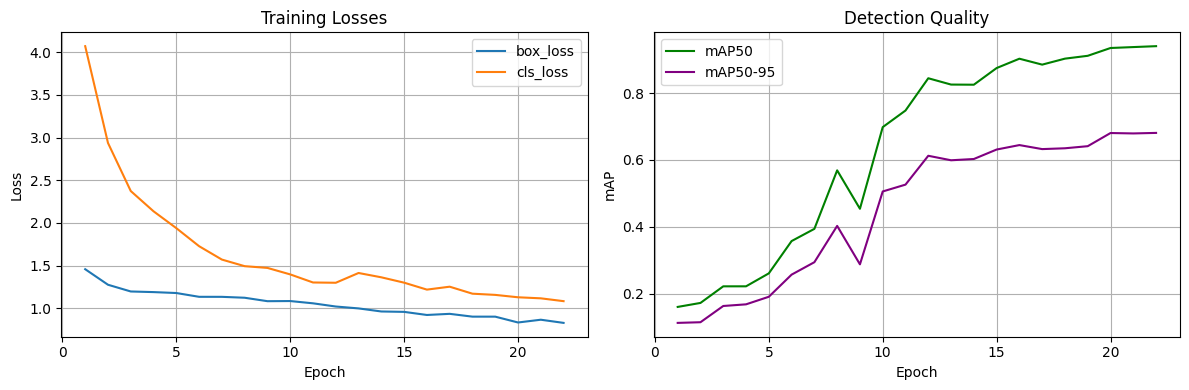

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/runs/detect/train/results.csv')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(df['epoch'], df['train/box_loss'], label='box_loss')
plt.plot(df['epoch'], df['train/cls_loss'], label='cls_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='green')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='purple')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.title('Detection Quality')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

files.download('/content/training_curves.png')

In [19]:
# Путь к папке с тестовыми фото
test_folder = '/content/drive/MyDrive/test'

#Путь к папке для сохранения результатов
results_folder = '/content/TestsResults'
os.makedirs(results_folder, exist_ok=True)

for img_name in os.listdir(test_folder):
    if img_name.endswith(('.jpg', '.png')):
        img_path = os.path.join(test_folder, img_name)
        results = model(img_path)
        save_path = os.path.join(results_folder, f'result_{img_name}')
        results[0].save(save_path)
        print(f'Обработано: {img_name}')


image 1/1 /content/drive/MyDrive/test/1000002687.jpg: 640x480 3 ozons, 6.9ms
Speed: 2.3ms preprocess, 6.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)
Обработано: 1000002687.jpg

image 1/1 /content/drive/MyDrive/test/XXXL (2).jpg: 480x640 1 ozon, 2 wbs, 6.6ms
Speed: 1.8ms preprocess, 6.6ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Обработано: XXXL (2).jpg

image 1/1 /content/drive/MyDrive/test/XXXL (19).jpg: 512x640 7 ozons, 6.6ms
Speed: 2.1ms preprocess, 6.6ms inference, 1.1ms postprocess per image at shape (1, 3, 512, 640)
Обработано: XXXL (19).jpg

image 1/1 /content/drive/MyDrive/test/XXXL (1).jpg: 480x640 4 ozons, 1 wb, 6.4ms
Speed: 2.0ms preprocess, 6.4ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)
Обработано: XXXL (1).jpg

image 1/1 /content/drive/MyDrive/test/XXXL (7).jpg: 480x640 2 ozons, 1 wb, 5.8ms
Speed: 2.0ms preprocess, 5.8ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Обработано: XXXL

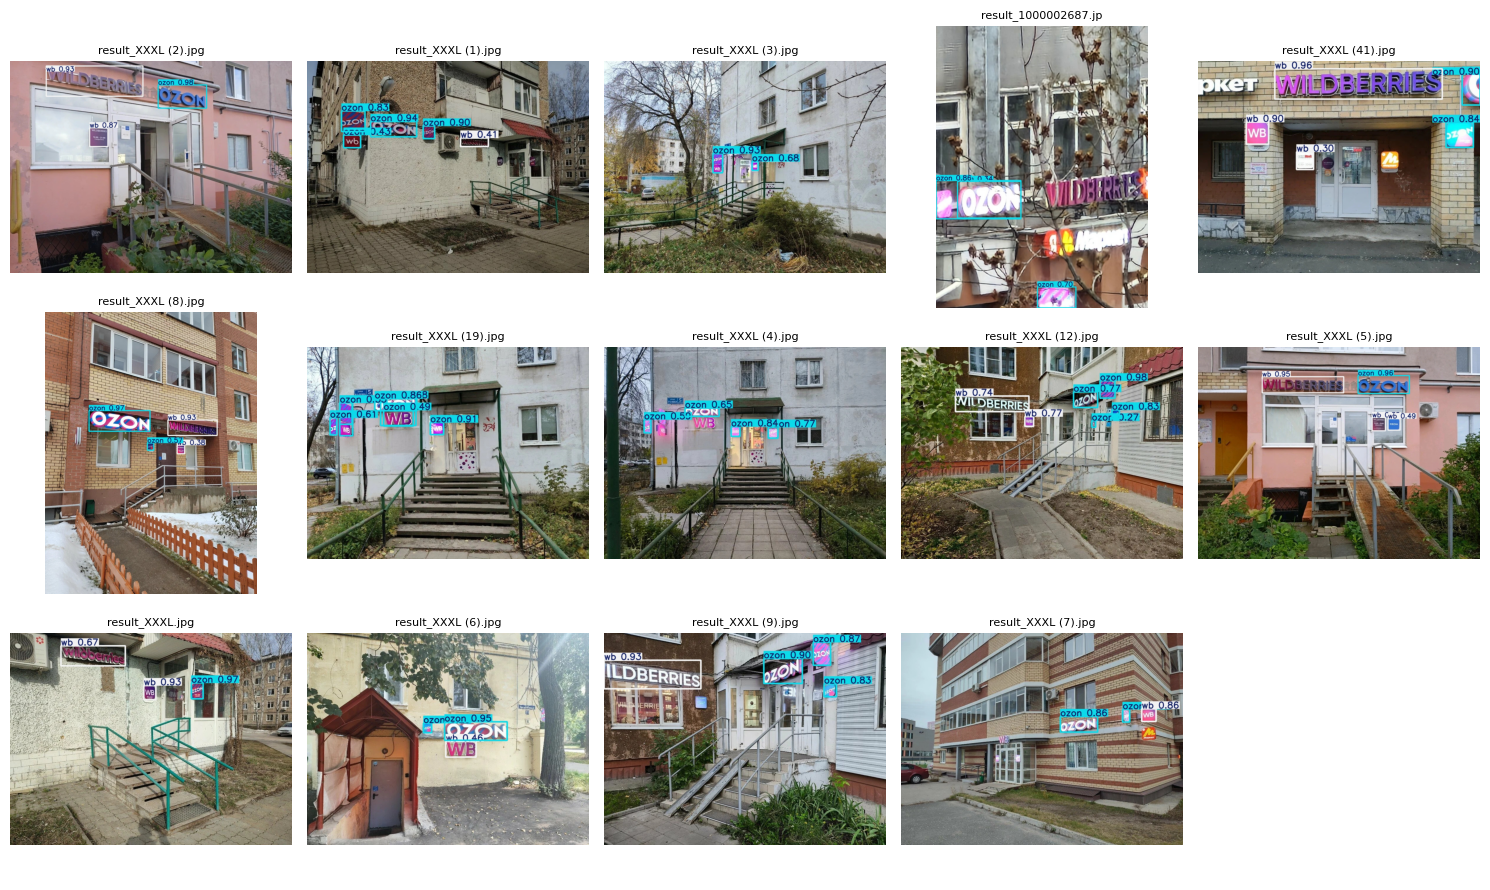

In [20]:
import matplotlib.image as mpimg
import os
images = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png'))]

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, img_name in enumerate(images):
    img_path = os.path.join(folder_path, img_name)
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(img_name[:20], fontsize=8)
    axes[i].axis('off')

for j in range(len(images), 15):
    axes[j].axis('off')

plt.tight_layout()
plt.show()